In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
plt.style.use('ggplot')

In [2]:
df = pd.read_csv("coaster_db.csv")

In [3]:
df.head()

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,...,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 56 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   coaster_name                   1087 non-null   object 
 1   Length                         953 non-null    object 
 2   Speed                          937 non-null    object 
 3   Location                       1087 non-null   object 
 4   Status                         874 non-null    object 
 5   Opening date                   837 non-null    object 
 6   Type                           1087 non-null   object 
 7   Manufacturer                   1028 non-null   object 
 8   Height restriction             831 non-null    object 
 9   Model                          744 non-null    object 
 10  Height                         965 non-null    object 
 11  Inversions                     932 non-null    float64
 12  Lift/launch system             795 non-null    o

In [5]:
df.describe()

,Inversions,year_introduced,latitude,longitude,speed1_value,speed_mph,height_value,height_ft,Inversions_clean,Gforce_clean
count,932.000000,1087.000000,812.000000,812.000000,937.000000,937.000000,965.000000,171.000000,1087.000000,362.000000
mean,1.547210,1994.986201,38.373484,-41.595373,53.850374,48.617289,89.575171,101.996491,1.326587,3.824006
std,2.114073,23.475248,15.516596,72.285227,23.385518,16.678031,136.246444,67.329092,2.030854,0.989998
min,0.000000,1884.000000,-48.261700,-123.035700,5.000000,5.000000,4.000000,13.100000,0.000000,0.800000
25%,0.000000,1989.000000,35.031050,-84.552200,40.000000,37.300000,44.000000,51.800000,0.000000,3.400000
50%,0.000000,2000.000000,40.289800,-76.653600,50.000000,49.700000,79.000000,91.200000,0.000000,4.000000
75%,3.000000,2010.000000,44.799600,2.778100,63.000000,58.000000,113.000000,131.200000,2.000000,4.500000
max,14.000000,2022.000000,63.230900,153.426500,240.000000,149.100000,3937.000000,377.300000,14.000000,12.000000


In [7]:
df.shape

(1087, 56)

In [9]:
df.columns

Index(['coaster_name', 'Length', 'Speed', 'Location', 'Status', 'Opening date',
       'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height',
       'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
       'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
       'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
       'Track layout', 'Fastrack available', 'Soft opening date.1',
       'Closing date', 'Opened', 'Replaced by', 'Website',
       'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
       'Single rider line available', 'Restraint Style',
       'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph', 'height_value', 'height_unit', 'height_ft',
       'Inversions_clean', 'Gforce_clean'],
      dtype='object')

In [11]:
df.dtypes

,0
coaster_name,object
Length,object
Speed,object
Location,object
Status,object
Opening date,object
Type,object
Manufacturer,object
Height restriction,object
Model,object


#DATA PREPERATION

In [17]:
df = df[['coaster_name',
    # 'Length', 'Speed',
    'Location', 'Status',
    # 'Opening date', 'Type',
    'Manufacturer',
    # 'Height restriction', 'Model', 'Height',
    #    'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
    #    'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
    #    'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
    #    'Track layout', 'Fastrack available', 'Soft opening date.1',
    #    'Closing date',
    # 'Opened',
    # 'Replaced by', 'Website',
      #  'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
      #  'Single rider line available', 'Restraint Style',
      #  'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean',
    # 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph',
    # 'height_value', 'height_unit',
    'height_ft',
       'Inversions_clean', 'Gforce_clean']].copy()

In [19]:
df.shape

(1087, 13)

In [22]:
df.dtypes

,0
coaster_name,object
Location,object
Status,object
Manufacturer,object
year_introduced,int64
latitude,float64
longitude,float64
Type_Main,object
opening_date_clean,object
speed_mph,float64


In [32]:
# changing opening columns type to datetime
df['opening_date_clean'] = pd.to_datetime(df['opening_date_clean'])

In [33]:
#rename some columns

In [48]:
df.columns

Index(['coaster_name', 'Location', 'Status', 'Manufacturer', 'year_introduced',
       'latitude', 'longitude', 'Type_Main', 'opening_date_clean', 'speed_mph',
       'height_ft', 'Inversions_clean', 'Gforce_clean'],
      dtype='object')

In [52]:
df = df.rename(columns={"coaster_name":"Coaster_Name" ,
                  "year_introduced" :"Year_Introduced" ,
                  'opening_date_clean':"Opening_Date",
                  'speed_mph' :"Speed_mph" ,
                    'height_ft':"Height_ft",
                  'Inversions_clean': "Inversions",
                  'Gforce_clean':"Gforce"
                  })

In [53]:
df.isna().sum()

,0
Coaster_Name,0
Location,0
Status,213
Manufacturer,59
Year_Introduced,0
latitude,275
longitude,275
Type_Main,0
Opening_Date,250
Speed_mph,150


In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df['Coaster_Name'].duplicated().sum()

np.int64(97)

In [60]:
df.loc[df.duplicated(subset=['Coaster_Name'])]

,Coaster_Name,Location,Status,Manufacturer,Year_Introduced,latitude,longitude,Type_Main,Opening_Date,Speed_mph,Height_ft,Inversions,Gforce
43,Crystal Beach Cyclone,Crystal Beach Park,Removed,Traver Engineering,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
60,Derby Racer,Revere Beach,Removed,Fred W. Pearce,1937,42.4200,-70.9860,Wood,1911-01-01,NaN,NaN,0,NaN
61,Blue Streak (Conneaut Lake),Conneaut Lake Park,Closed,NaN,1938,41.6349,-80.3180,Wood,1938-05-23,50.0,NaN,0,NaN
167,Big Thunder Mountain Railroad,Other,NaN,Arrow Development (California and Florida)Dyna...,1980,NaN,NaN,Steel,NaT,35.0,NaN,0,NaN
237,Thunder Run (Canada's Wonderland),Canada's Wonderland,Operating,Mack Rides,1986,43.8427,-79.5423,Steel,1981-05-23,39.8,32.8,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,Lil' Devil Coaster,Six Flags Great Adventure,Operating,Zamperla,2021,40.1343,-74.4434,Steel,1999-01-01,NaN,NaN,0,NaN
1064,Little Dipper (Conneaut Lake Park),Conneaut Lake Park,Operating,Allan Herschell Company,2021,41.6343,-80.3165,Steel,1950-01-01,NaN,NaN,0,NaN
1080,Iron Gwazi,Busch Gardens Tampa Bay,Under construction,Rocky Mountain Construction,2022,28.0339,-82.4231,Steel,NaT,76.0,NaN,2,NaN
1082,American Dreier Looping,Other,NaN,Anton Schwarzkopf,2022,NaN,NaN,Steel,NaT,53.0,NaN,3,4.7


In [64]:
df = df.drop_duplicates(subset=['Coaster_Name'])

In [66]:
df.reset_index(drop=True , inplace=True)

# Feature Understanding

- Plotting Feature Distributions
- KDE
- BOXPLOT

Text(0, 0.5, 'Count OF Coaster')

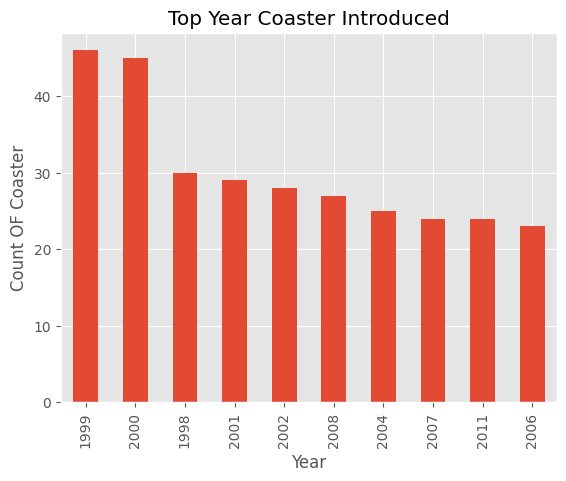

In [84]:
ax = df['Year_Introduced'].value_counts()\
  .head(10) \
  .plot(kind='bar' , title='Top Year Coaster Introduced')

ax.set_xlabel("Year")
ax.set_ylabel("Count OF Coaster")

Text(0.5, 1.0, 'Coaster Speed Distribution')

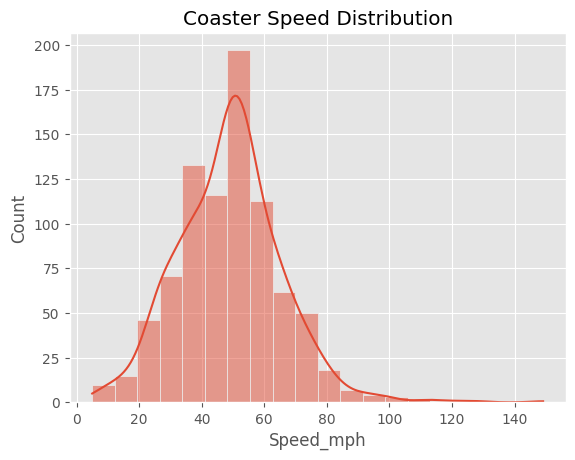

In [91]:
sns.histplot(df['Speed_mph'] , kde=True , bins=20)
plt.title("Coaster Speed Distribution")



# KEY POINT

-Most of the coaster had average speed betwenn 20 to 70 mph


## Feature Relationship

- Scatterplot
- Heatmap Correlation
- Pairplot
- Groupby Comparisons


Text(0.5, 1.0, 'SPEED VS HEIGHT')

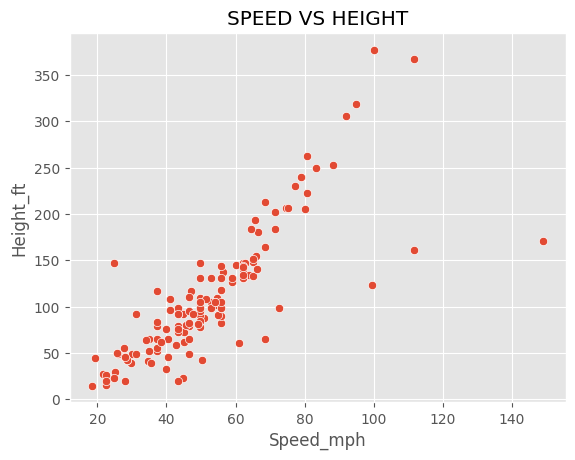

In [103]:
sns.scatterplot(data = df , x='Speed_mph' , y='Height_ft' )
plt.title("SPEED VS HEIGHT")

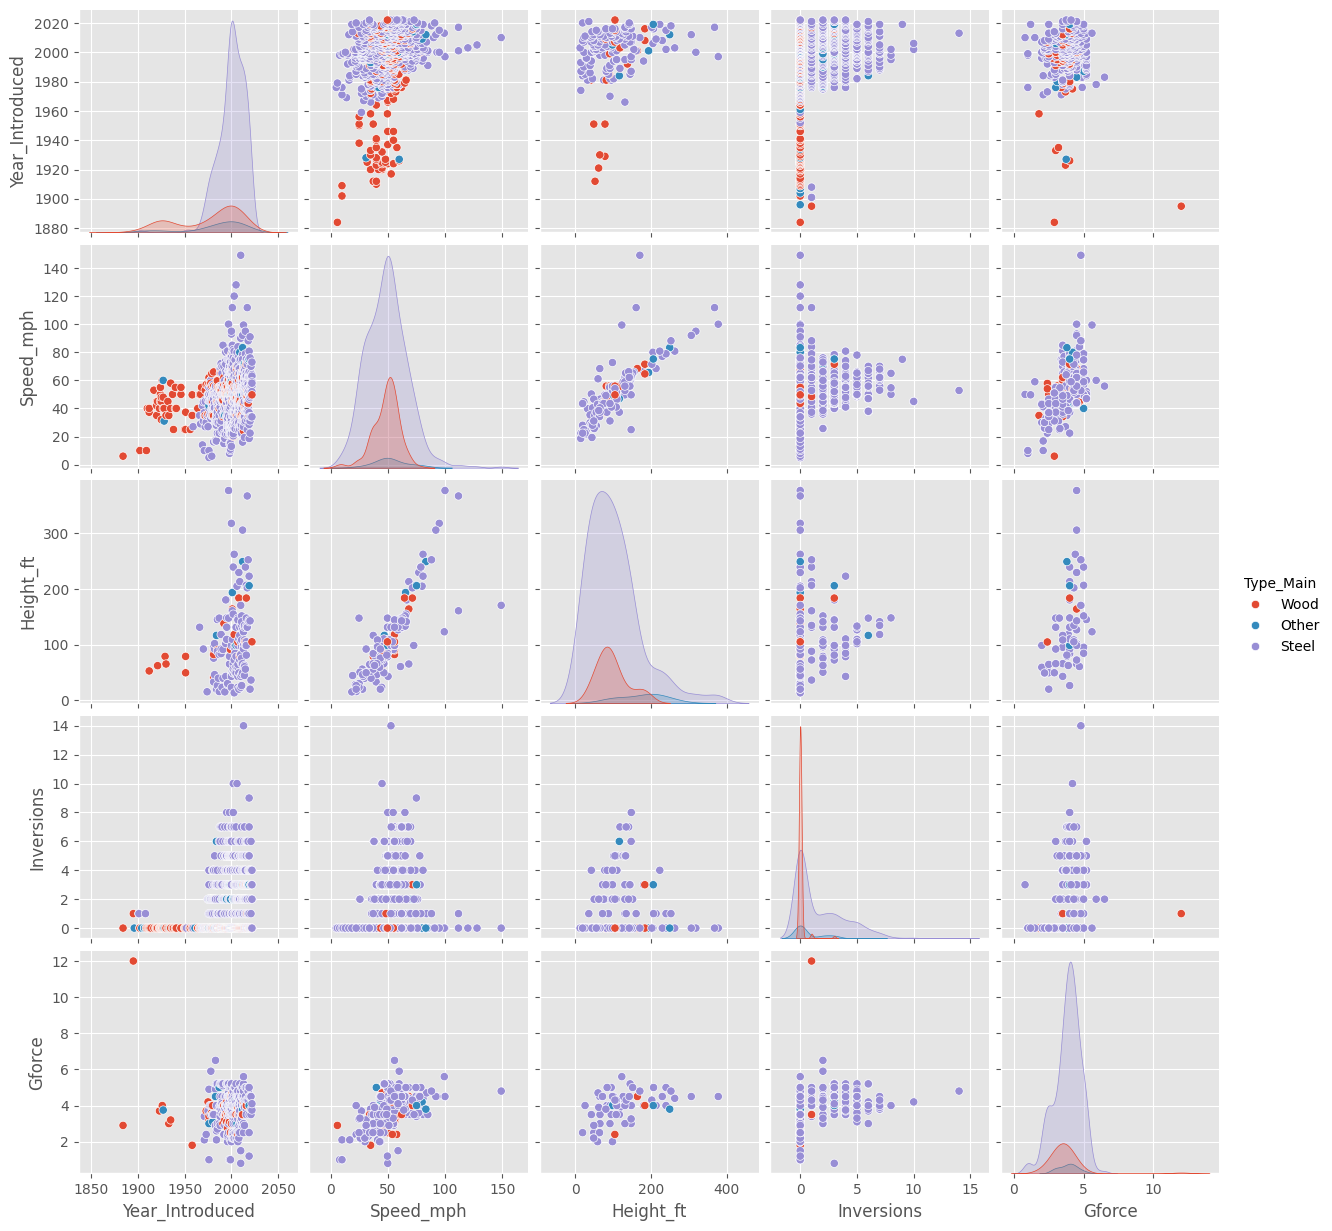

In [105]:
sns.pairplot(data=df , vars=['Year_Introduced' , 'Speed_mph' , 'Height_ft' , 'Inversions' , 'Gforce'] , hue='Type_Main')

In [106]:
df[['Year_Introduced' , 'Speed_mph' , 'Height_ft' , 'Inversions' , 'Gforce']].dropna().corr()

,Year_Introduced,Speed_mph,Height_ft,Inversions,Gforce
Year_Introduced,1.000000,0.171978,0.135413,-0.209887,0.160247
Speed_mph,0.171978,1.000000,0.733999,-0.028705,0.607383
Height_ft,0.135413,0.733999,1.000000,-0.079736,0.466482
Inversions,-0.209887,-0.028705,-0.079736,1.000000,0.275991
Gforce,0.160247,0.607383,0.466482,0.275991,1.000000


In [114]:
df_corr = df[['Year_Introduced' , 'Speed_mph' , 'Height_ft' , 'Inversions' , 'Gforce']].dropna().corr()

<Axes: >

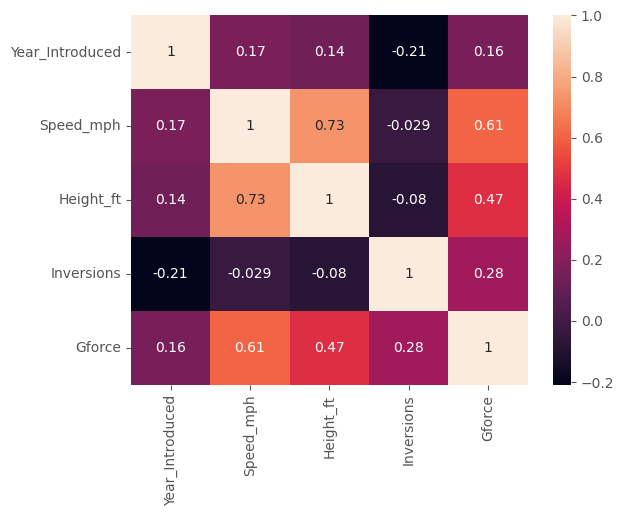

In [116]:
sns.heatmap(df_corr , annot=True)

In [127]:
numeric_col = df.select_dtypes(include='number')

<Axes: >

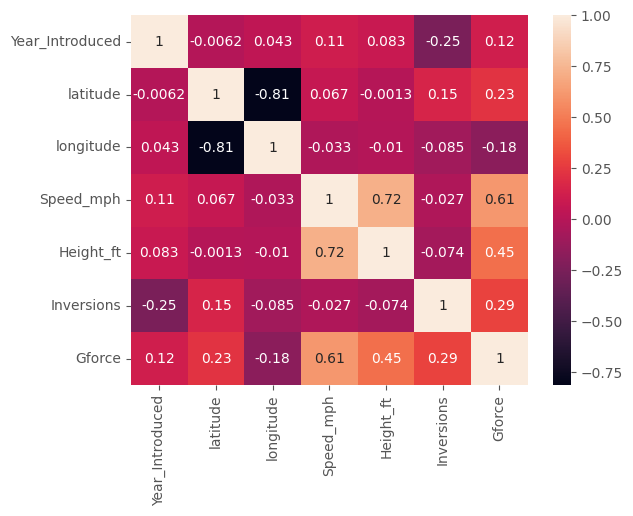

In [126]:
sns.heatmap(numeric_col.dropna().corr() , annot=True )

# QUESTION

What are the locations with the fastest roller coaster (minimum 10 coaster)



In [161]:
df2 = df[df['Location']!="Other"]


In [169]:
df2 = df2['Location'].value_counts().sort_values(ascending=False).head(10)

Text(0.5, 1.0, 'Top 10 Roller Coaste by Locations ')

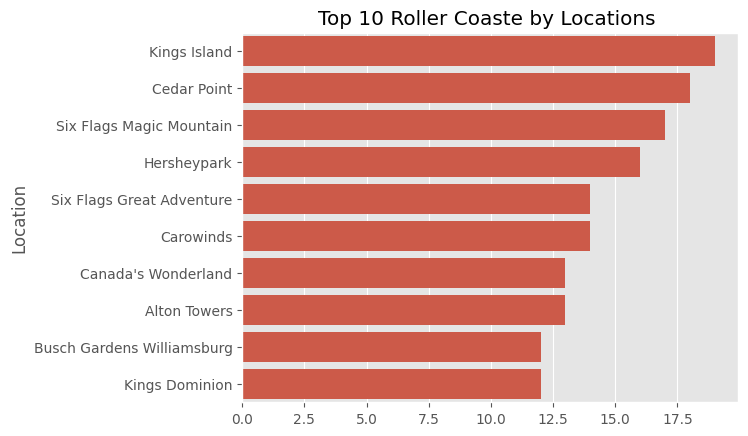

In [171]:
sns.barplot(y=df2.index , x=df2.values)
plt.title("Top 10 Roller Coaste by Locations ")

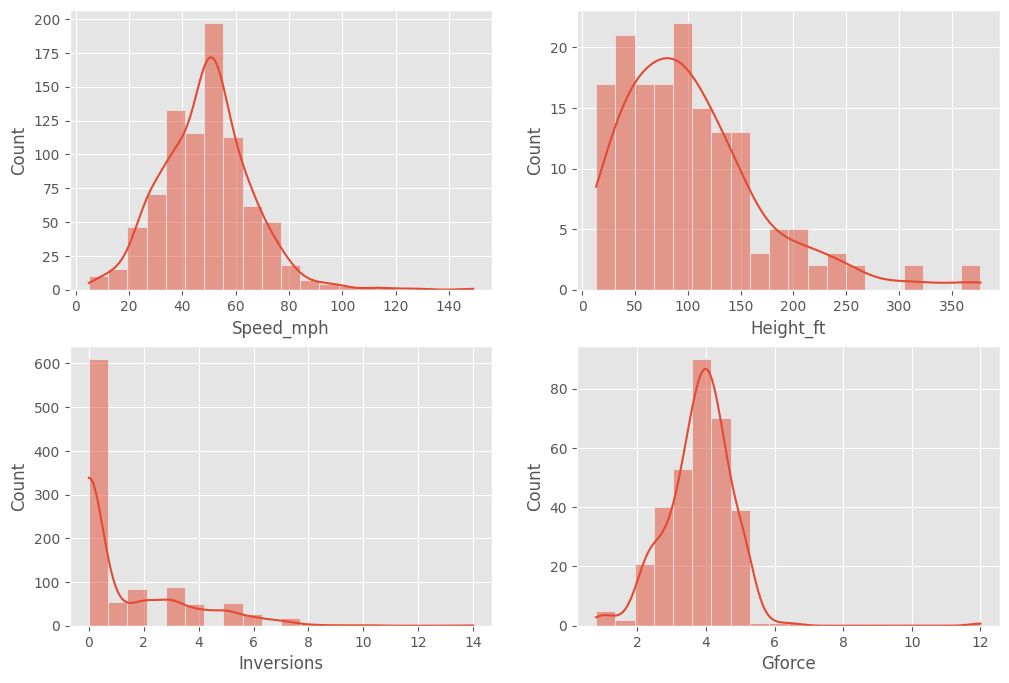

In [196]:
plt.figure(figsize=(12 , 8))


plt.subplot(2 , 2, 1)
sns.histplot(df['Speed_mph'] , kde=True , bins=20)


plt.subplot(2,2,2)
sns.histplot(df['Height_ft'] , kde=True , bins=20)

plt.subplot(2,2,3)
sns.histplot(df['Inversions'] , kde=True , bins=20)

plt.subplot(2,2,4)
sns.histplot(df['Gforce'] , kde=True , bins=20)

plt.savefig('Dashboard2.png', bbox_inches='tight', dpi=150)

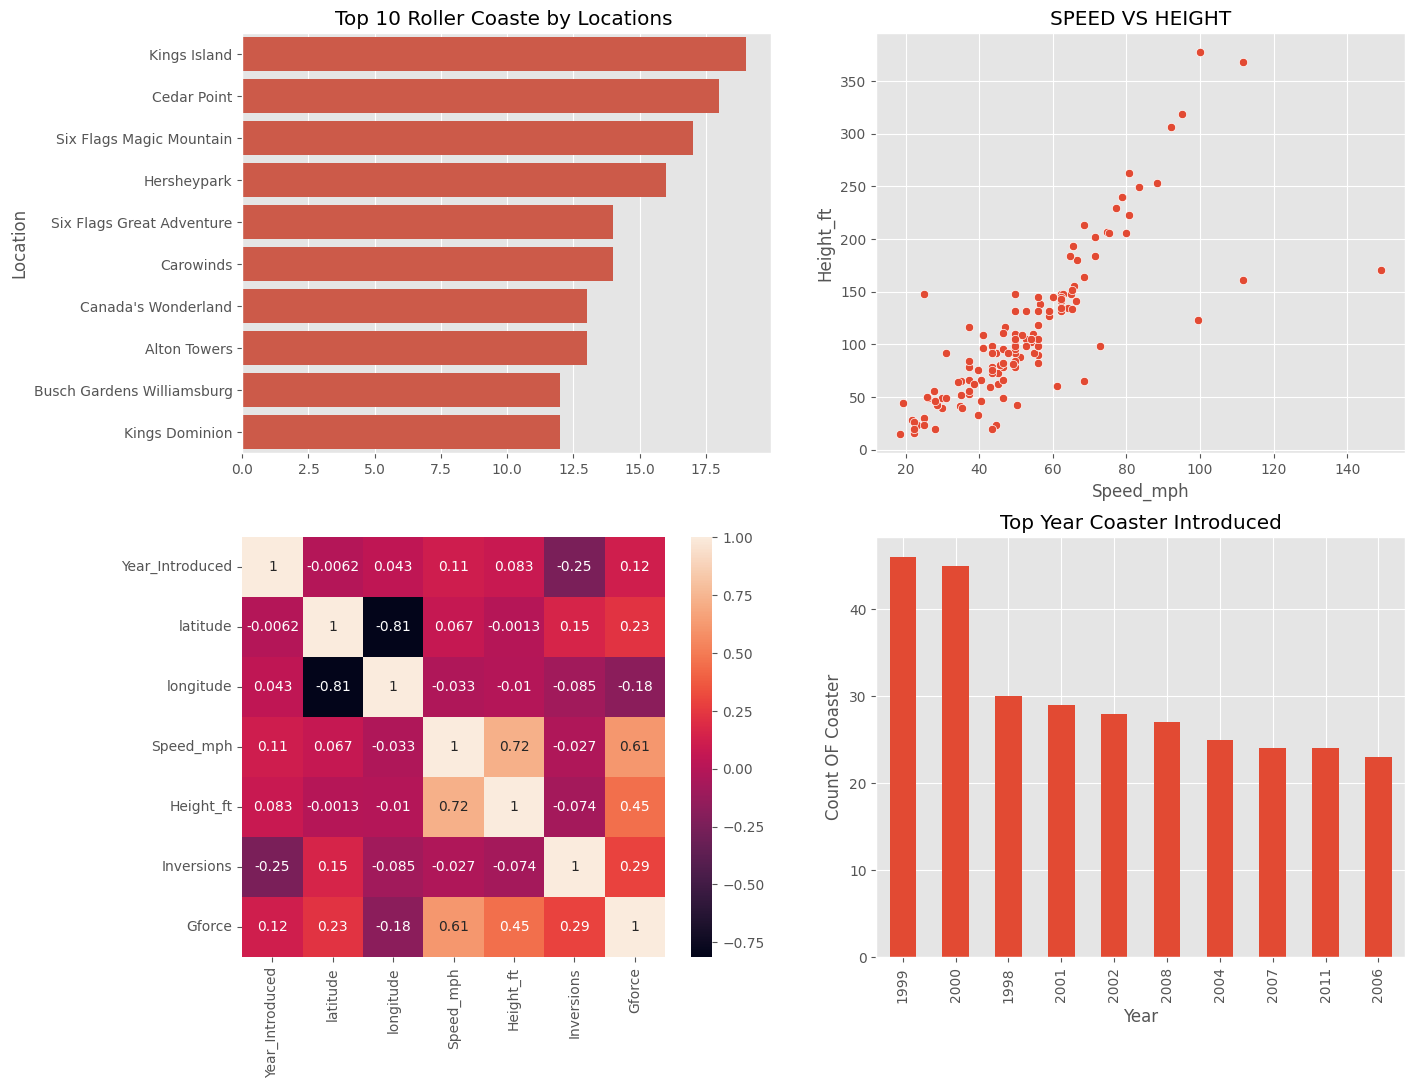

In [195]:
plt.figure(figsize=(15,12))


plt.subplot(2,2,1)
sns.barplot(y=df2.index , x=df2.values)
plt.title("Top 10 Roller Coaste by Locations ")


plt.subplot(2,2,2)
sns.scatterplot(data = df , x='Speed_mph' , y='Height_ft' )
plt.title("SPEED VS HEIGHT")


plt.subplot(2,2,4)
ax = df['Year_Introduced'].value_counts()\
  .head(10) \
  .plot(kind='bar' , title='Top Year Coaster Introduced')

ax.set_xlabel("Year")
ax.set_ylabel("Count OF Coaster")

# sns.barplot(x=df['Year_Introduced'].value_counts().head(10).index , y=df['Year_Introduced'].value_counts().head(10).values)
# plt.title("TOP Year Of Coaster Indtroduced")


plt.subplot(2,2,3)
sns.heatmap(numeric_col.dropna().corr() , annot=True )


plt.savefig('Dashboard1.png', bbox_inches='tight', dpi=150)